# `jitr` Quickstart: $\alpha$ elastic scattering on $^{48}$Ca at 29 MeV

We will 
- compile a solver for a particular reaction and kinematics
-  define a parametric potential and generate samples of the interaction parameters
-  perform a Bayesian calibration of the parameters to experimental data from [EXFOR](https://www-nds.iaea.org/exfor/servlet/X4sGetSubent?reqx=14669&subID=150567004&plus=1)

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats

### Read in data

In [2]:
import pandas as pd

df = pd.read_csv("./alpha_ca48_ratio_ruth.txt", names=["angle", "xs"], sep=r"\s+")

In [3]:
df.head()

,angle,xs
0,14.718,0.57851
1,15.562,0.50721
2,15.985,0.46463
3,16.408,0.41639
4,18.088,0.46469


In [4]:
x = df["angle"].to_numpy()
y = df["xs"].to_numpy()
y_err = 0.05 * y + 0.01

## Set up reaction and compile solver

In [5]:
from jitr.reactions.reaction import Reaction
from jitr.rmatrix import Solver as SolverKernel
from jitr.utils import utils
from jitr.xs import elastic

# define reaction system
alpha = (4, 2)
Ca48 = (48, 20)
reaction = Reaction(target=Ca48, projectile=alpha, process="El")

# calculate kinematics for a given lab energy
energy_lab = 28.2
kinematics = reaction.kinematics(energy_lab)

# set the channel radius, number of nodes, and number of partial waves
interaction_range_fm = 1.2 * (48 ** (1 / 3) + 4 ** (1 / 3)) + 2
channel_radius_dimensionless = utils.suggested_dimensionless_channel_radius(
    interaction_range_fm, kinematics.k
)
channel_radius = channel_radius_dimensionless / kinematics.k
N = utils.suggested_basis_size(channel_radius_dimensionless)
lmax = 180

# build a solver for the system and reaction of interest
print(f"Compiling solver for {reaction} at {energy_lab} MeV")
print(f" - channel radius {channel_radius:1.2f} fm")
print(f" - {N} nodes")
print(f" - {lmax} partial waves")

solver = elastic.DifferentialWorkspace.build_from_system(
    reaction=reaction,
    kinematics=kinematics,
    channel_radius_fm=channel_radius,
    solver=SolverKernel(N),
    lmax=lmax,
    angles=np.deg2rad(x),
)
rgrid = solver.radial_grid()
# jit warmup
_ = solver.xs(central_potential=np.zeros_like(solver.radial_grid()))
print("Done!")

Compiling solver for 48-Ca(alpha,el) at 28.2 MeV
 - channel radius 11.19 fm
 - 40 nodes
 - 180 partial waves
Done!


## Define the interaction model and parameters

In [6]:
from jitr.optical_potentials.potential_forms import (
    coulomb_charged_sphere as coulomb,
)
from jitr.optical_potentials.potential_forms import (
    woods_saxon_safe as ws,
)

In [7]:
def U_central(r, Vv, Wv, Rv, av, Rw, aw):
    return -Vv * ws(r, Rv, av) - 1j * Wv * ws(r, Rw, aw)


def V_Coulomb(r, Zz, RC):
    return coulomb(r, Zz, RC)

In [8]:
def calculate_xs_ratio(theta):
    Vv, Wv, rv, av, rw, aw, rC = theta
    A_factor = reaction.target.A ** (1 / 3) + reaction.projectile.A ** (1 / 3)
    Zz = reaction.target.Z * reaction.projectile.Z
    xs = solver.xs(
        central_potential=U_central(
            rgrid,
            Vv,
            Wv,
            rv * A_factor,
            av,
            rw * A_factor,
            aw,
        ),
        coulomb_potential=V_Coulomb(rgrid, Zz, rC * A_factor),
    )
    return xs.dsdo / solver.rutherford

## Comparison to data

In [9]:
log_err_term = np.sum(np.log(2 * np.pi * y_err))


def log_likelihood(theta):
    y_pred = calculate_xs_ratio(theta)
    chi2 = np.sum((y_pred - y) ** 2 / y_err * 2)
    logl = -0.5 * (chi2 + log_err_term)
    return logl

## Maximum likelihood estimation (MLEM)

Now that we have the solver compiled, fitting to data using MLEM is easy. Notice that, since `y_err` is fixed and there is no correlation in the errors, MLEM in this case is in fact identical to simple least squares.

In [10]:
from scipy.optimize import minimize

In [33]:
%%time
optimum = minimize(
    lambda x: -log_likelihood(x),
    np.array([185, 20, 1.0, 0.6, 1.0, 0.6, 1.2]),
    method="Nelder-Mead",
    bounds=np.array(
        [
            [150, 250],
            [0, 100],
            [0.9, 1.3],
            [0.4, 0.9],
            [0.6, 1.3],
            [0.4, 0.9],
            [0.9, 1.3],
        ]
    ),
    options={
        "maxiter": 5000,
        "adaptive": True,
    },
)
optimum

CPU times: user 11.2 s, sys: 2.99 ms, total: 11.2 s
Wall time: 11.2 s


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -379.9442512125232
             x: [ 1.794e+02  2.627e+01  1.056e+00  5.159e-01  9.627e-01
                  4.000e-01  9.000e-01]
           nit: 1597
          nfev: 2407
 final_simplex: (array([[ 1.794e+02,  2.627e+01, ...,  4.000e-01,
                         9.000e-01],
                       [ 1.794e+02,  2.627e+01, ...,  4.000e-01,
                         9.000e-01],
                       ...,
                       [ 1.794e+02,  2.627e+01, ...,  4.000e-01,
                         9.000e-01],
                       [ 1.794e+02,  2.627e+01, ...,  4.000e-01,
                         9.000e-01]], shape=(8, 7)), array([-3.799e+02, -3.799e+02, -3.799e+02, -3.799e+02,
                       -3.799e+02, -3.799e+02, -3.799e+02, -3.799e+02]))

In [34]:
y_mlem = calculate_xs_ratio(optimum.x)

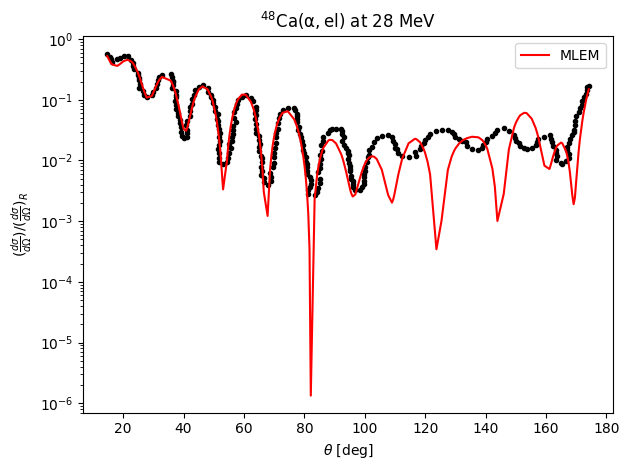

In [35]:
plt.figure()
plt.scatter(df["angle"], df["xs"], color="k", marker=".")
plt.plot(df["angle"], y_mlem, color="r", label="MLEM")
plt.yscale("log")
plt.legend()
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$(\frac{d\sigma}{d\Omega}) / (\frac{d\sigma}{d\Omega})_{R}$")
plt.title(f"${reaction.reaction_latex}$ at {kinematics.Elab:1.0f} MeV")
plt.tight_layout()
plt.show()

Not a bad result! Notice, however, the degradation of the quality of the fit at backwards angles. This is due to model discrepancy - the simple 7 parameter model we're using is not flexible enough to resolve the full reaction dynamics.

## Bayesian calibration
To do Bayesian calibration, we must first define a prior. Then, comb 

In [36]:
prior_means = np.array([185, 20, 1.0, 0.6, 1.0, 0.5, 1.2])
prior_std_devs = np.array([10, 5, 0.2, 0.1, 0.2, 0.2, 0.1])
prior = stats.multivariate_normal(
    mean=prior_means, 
    cov=np.diag(prior_std_devs) ** 2,
)

### Sampling from the posterior distribution
There are many open source sampler and calibration libraries out there in Python. In this example, we will use a neat one: [dynesty](https://dynesty.readthedocs.io/en/stable/quickstart.html). Rather than the usual Markov-Chain Monte Carlo, this does something called nested sampling.

In [37]:
import dynesty

In [38]:
sampler_dyn = dynesty.NestedSampler(
    log_likelihood,
    lambda x: stats.norm.ppf(x, loc=prior_means, scale=prior_std_devs),
    prior_means.size,
    nlive=300,
    sample="rwalk",
)
sampler_dyn.run_nested(dlogz=0.5, print_progress=True)

3213it [05:02, 10.63it/s, +300 | bound: 8 | nc: 1 | ncall: 67679 | eff(%):  5.214 | loglstar:   -inf < 379.890 <    inf | logz: 369.844 +/-  0.180 | dlogz:  0.002 >  0.500]  


In [39]:
results_dyn = sampler_dyn.results
flat_dynesty = results_dyn.samples_equal()

print(f"Posterior samples: {len(flat_dynesty)}")
print(f"log Z = {results_dyn.logz[-1]:.2f} ± {results_dyn.logzerr[-1]:.2f}")
print(f"Efficiency: {results_dyn.eff:.2f} %")

Posterior samples: 3513
log Z = 369.84 ± 0.27
Efficiency: 5.21 %


### Plot posterior distribution

In [40]:
import corner

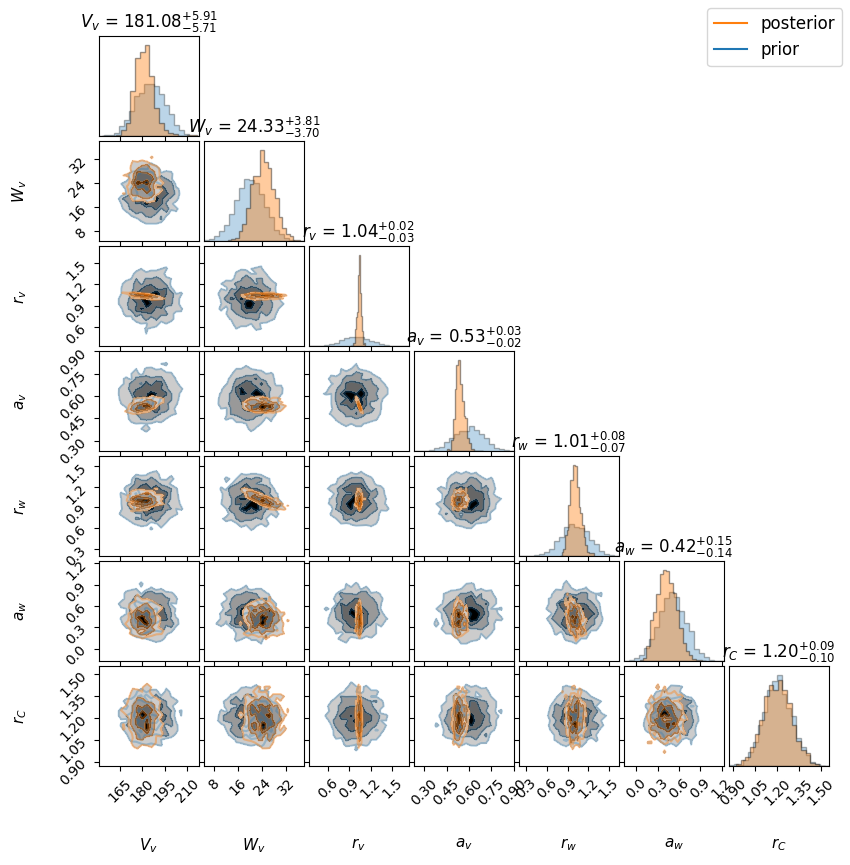

In [46]:
n_corner = 2000
prior_samples = prior.rvs(n_corner)
idx_d = np.random.default_rng(42).choice(
    len(flat_dynesty), min(n_corner, len(flat_dynesty)), replace=False
)

fig = plt.figure(figsize=(8, 8))


def corner_kwargs(color, alpha=0.4):
    return dict(
        labels=[
            r"$V_v$",
            r"$W_v$",
            r"$r_v$",
            r"$a_v$",
            r"$r_w$",
            r"$a_w$",
            "$r_C$",
        ],
        label_kwargs={"fontsize": 11},
        show_titles=True,
        plot_datapoints=False,
        plot_density=False,
        plot_contours=True,
        fill_contours=True,
        no_fill_contours=False,
        contour_kwargs={
            "colors": color,
            "linewidths": 1.5,
            "alpha": alpha,
        },
        hist_kwargs={
            "density": True,
            "histtype": "stepfilled",
            "alpha": alpha,
            "color": color,
            "edgecolor": "k",
        },
        labelpad=0.4,
    )


corner.corner(
    prior_samples,
    fig=fig,
    **corner_kwargs("tab:blue", alpha=0.3),
)
corner.corner(
    flat_dynesty[idx_d],
    fig=fig,
    **corner_kwargs("tab:orange"),
)

# Legend
from matplotlib.lines import Line2D

handles = [
    Line2D([0], [0], color="tab:orange", label="posterior"),
    Line2D([0], [0], color="tab:blue", label="prior"),
]
fig.legend(handles=handles, loc="upper right", fontsize=12)

### Calculate predictive posterior

In [47]:
n_pred = 500
idx_d_pred = np.random.default_rng(43).choice(len(flat_dynesty), n_pred, replace=False)
y_pred_dynesty = np.array([calculate_xs_ratio(s) for s in flat_dynesty[idx_d_pred]])

### Plot predictive posterior distribution

We will plot the inner 90% credible interval (CI) of the posterior predictive distribution.

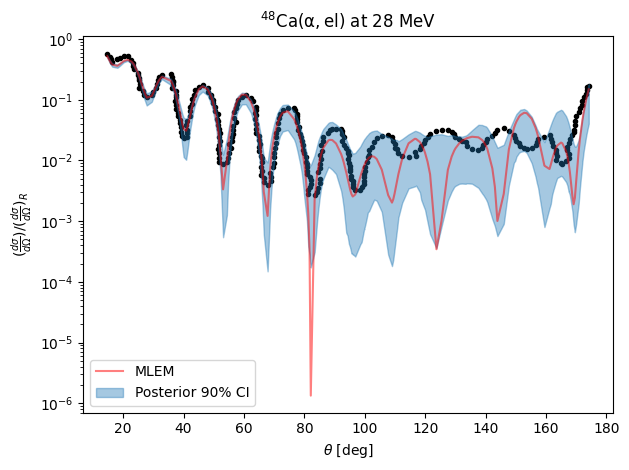

In [48]:
plt.figure()
plt.scatter(df["angle"], df["xs"], color="k", marker=".")
plt.plot(df["angle"], y_mlem, alpha=0.5, color="r", label="MLEM")
plt.fill_between(
    df["angle"],
    *np.percentile(y_pred_dynesty, [5, 95], axis=0),
    color="tab:blue",
    alpha=0.4,
    label="Posterior 90% CI",
)
plt.yscale("log")
plt.legend()
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$(\frac{d\sigma}{d\Omega}) / (\frac{d\sigma}{d\Omega})_{R}$")
plt.title(f"${reaction.reaction_latex}$ at {kinematics.Elab:1.0f} MeV")
plt.tight_layout()
plt.show()